In [37]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report

In [38]:
train_data = pd.read_csv("/content/fetal_health_train_processed.csv")
test_data = pd.read_csv("/content/fetal_health_test_processed.csv")

X_train = train_data.drop("fetal_health", axis=1)
y_train = train_data["fetal_health"]

X_test = test_data.drop("fetal_health", axis=1)
y_test = test_data["fetal_health"]

print(X_train.shape)
print(X_test.shape)

(1479, 10)
(634, 10)


LOGISTIC REGRESSION

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8958990536277602

Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       497
           2       0.73      0.58      0.65        90
           3       0.78      0.77      0.77        47

    accuracy                           0.90       634
   macro avg       0.81      0.77      0.79       634
weighted avg       0.89      0.90      0.89       634



K-Nearest Neighbours

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.9384858044164038

Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.98      0.97       497
           2       0.86      0.71      0.78        90
           3       0.91      0.91      0.91        47

    accuracy                           0.94       634
   macro avg       0.91      0.87      0.89       634
weighted avg       0.94      0.94      0.94       634



Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9321766561514195

Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.97      0.96       497
           2       0.81      0.72      0.76        90
           3       0.90      0.94      0.92        47

    accuracy                           0.93       634
   macro avg       0.89      0.88      0.88       634
weighted avg       0.93      0.93      0.93       634



Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9526813880126183

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.99      0.97       497
           2       0.91      0.77      0.83        90
           3       0.92      0.96      0.94        47

    accuracy                           0.95       634
   macro avg       0.93      0.90      0.91       634
weighted avg       0.95      0.95      0.95       634



SVM-Support Vector Machine

In [47]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.919558359621451

Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.97      0.95       497
           2       0.78      0.66      0.71        90
           3       0.98      0.89      0.93        47

    accuracy                           0.92       634
   macro avg       0.90      0.84      0.87       634
weighted avg       0.92      0.92      0.92       634



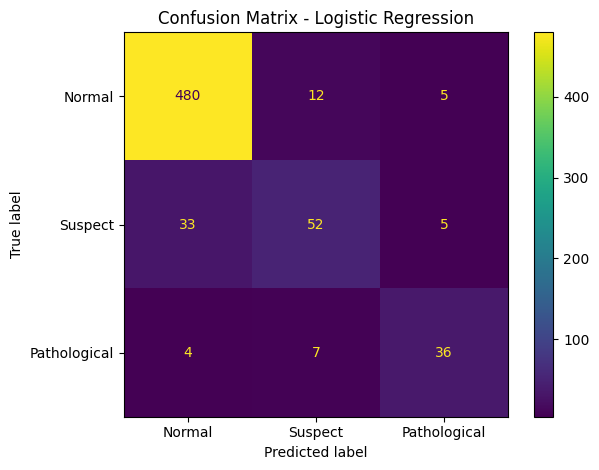

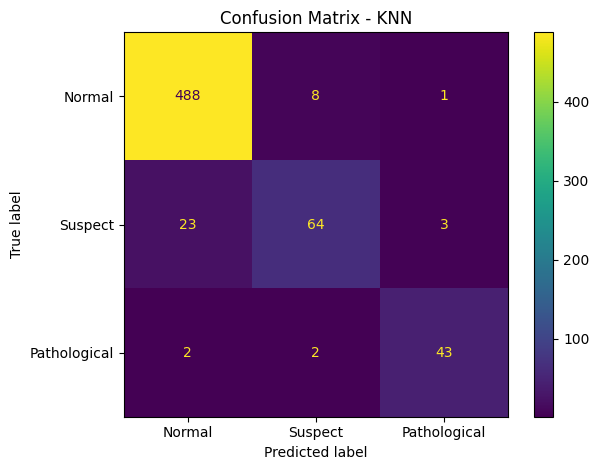

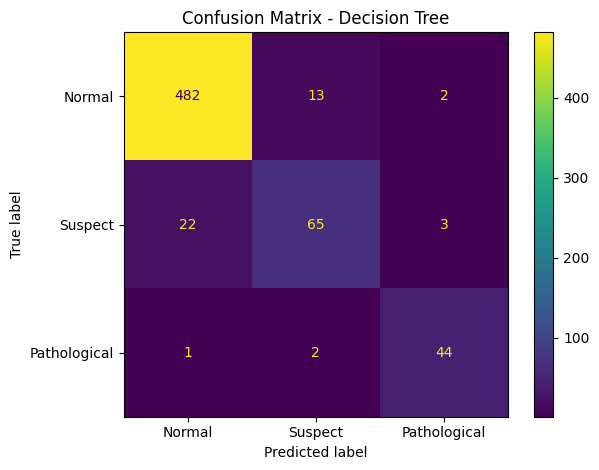

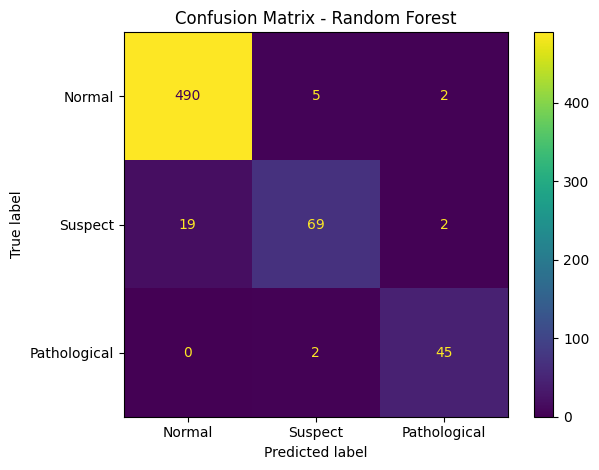

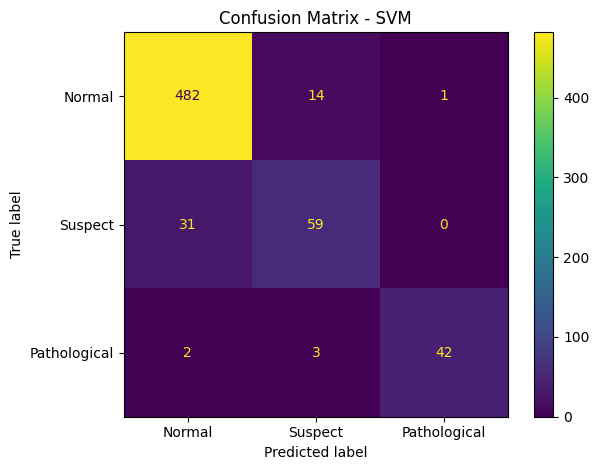

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": (y_test, y_pred_lr),
    "KNN": (y_test, y_pred_knn),
    "Decision Tree": (y_test, y_pred_dt),
    "Random Forest": (y_test, y_pred_rf),
    "SVM": (y_test, y_pred_svm)
}

for model_name, (y_true, y_pred) in models.items():

    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Normal", "Suspect", "Pathological"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

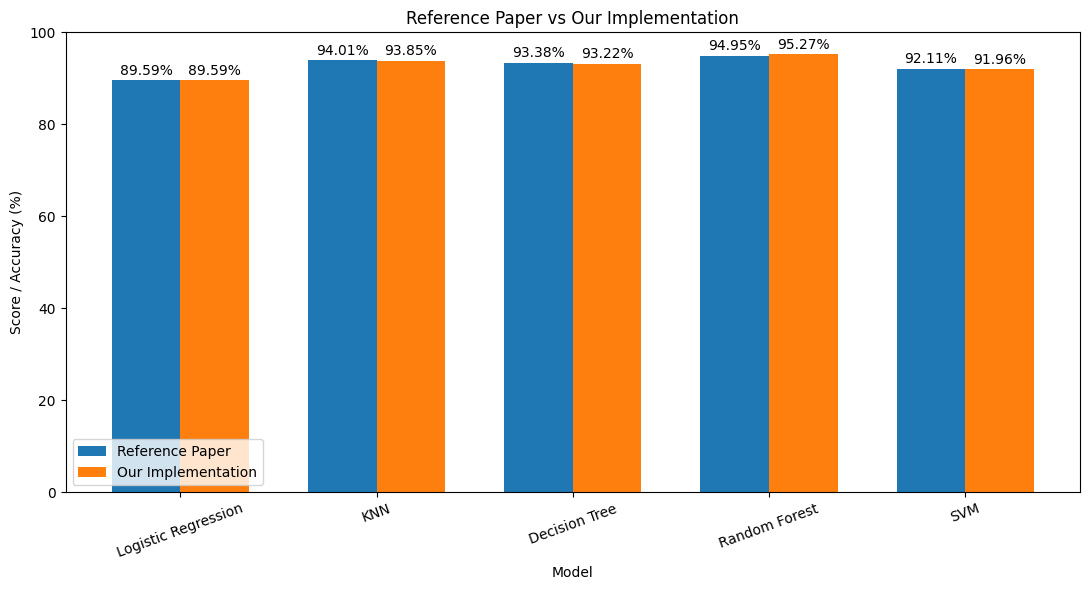

In [49]:
import matplotlib.pyplot as plt
import numpy as np

model_names = [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "SVM"
]

reference_scores = [
    89.5899,
    94.0063,
    93.3754,
    94.9527,
    92.1136
]

your_scores = [
    accuracy_score(y_test, y_pred_lr) * 100,
    accuracy_score(y_test, y_pred_knn) * 100,
    accuracy_score(y_test, y_pred_dt) * 100,
    accuracy_score(y_test, y_pred_rf) * 100,
    accuracy_score(y_test, y_pred_svm) * 100
]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(11, 6))

bars1 = plt.bar(
    x - width/2,
    reference_scores,
    width,
    label="Reference Paper"
)

bars2 = plt.bar(
    x + width/2,
    your_scores,
    width,
    label="Our Implementation"
)

plt.xlabel("Model")
plt.ylabel("Score / Accuracy (%)")
plt.title("Reference Paper vs Our Implementation")
plt.xticks(x, model_names, rotation=20)
plt.ylim(0, 100)
plt.legend()

# Add values above bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()